# Clonmel Triathlon Results — Debug Orchestrator

Thin notebook that drives the three pipeline modules:
- **`parse_input.py`** — reads `Clonmel.txt` → raw `DataFrame`
- **`metrics.py`** — adds percentile columns
- **`visualise.py`** — per-athlete split charts

Edit logic in the `.py` files; use this notebook to run and inspect intermediate state.

## Setup — auto-reload modules

In [20]:
%load_ext autoreload
%autoreload 2

import pandas as pd

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', None)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1 · Input parsing (`parse_input.py`)

In [21]:
from parse_input import load_results, parse_race_line

df_raw = load_results('Clonmel.txt')
print(f'Rows parsed: {len(df_raw)}')
df_raw.head(10)

Rows parsed: 290


,Place,Bib,Name,Age_Group,Group_Rank,Class,Club,Swim,T1,Bike,T2,Run,Finish
0,1,215,Sean McMahon,OverAll,1.0,Open,Wicklow TC,0 days 00:08:31,0 days 00:00:47,0 days 00:31:39,0 days 00:00:54,0 days 00:15:59,0 days 00:57:50
1,2,145,Christopher Horgan,OverAll,2.0,Open,Mallow TC,0 days 00:08:42,0 days 00:00:52,0 days 00:31:55,0 days 00:00:53,0 days 00:16:07,0 days 00:58:29
2,3,130,Denis Hegarty,OverAll,3.0,Open,Tralee Tri Club,0 days 00:09:28,0 days 00:01:13,0 days 00:31:39,0 days 00:01:06,0 days 00:16:38,0 days 01:00:04
3,4,185,Ciaran Kyne,From 25 to 29,1.0,Open,Piranha Triathlon Club,0 days 00:09:34,0 days 00:01:19,0 days 00:31:24,0 days 00:01:02,0 days 00:17:05,0 days 01:00:24
4,5,327,John paul Vereker,From 40 to 44,1.0,Open,Waterford Triathlon Club,0 days 00:09:54,0 days 00:01:00,0 days 00:32:36,0 days 00:00:57,0 days 00:17:33,0 days 01:02:00
5,6,5,Enda Bagnall,From 45 to 49,1.0,Open,Eden Tri Club,0 days 00:09:51,0 days 00:01:24,0 days 00:32:14,0 days 00:01:02,0 days 00:17:45,0 days 01:02:16
6,7,322,Conor Talty,From 35 to 39,1.0,Open,Piranha Triathlon Club,0 days 00:10:09,0 days 00:01:32,0 days 00:31:45,0 days 00:01:31,0 days 00:17:20,0 days 01:02:17
7,8,113,Scott Graham,From 35 to 39,2.0,Open,Wicklow TC,0 days 00:09:25,0 days 00:01:03,0 days 00:33:18,0 days 00:01:13,0 days 00:17:52,0 days 01:02:51
8,9,303,James Ryan,From 35 to 39,3.0,Open,,0 days 00:10:04,0 days 00:01:28,0 days 00:33:02,0 days 00:01:02,0 days 00:17:18,0 days 01:02:54
9,10,44,Brendan Cassidy,From 35 to 39,4.0,Open,Cork Triathlon Club,0 days 00:11:21,0 days 00:01:16,0 days 00:31:06,0 days 00:01:09,0 days 00:18:15,0 days 01:03:07


In [22]:
# Debug a single raw line — paste any problem line here
test_line = ''
if test_line:
    print(parse_race_line(test_line))

In [23]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290 entries, 0 to 289
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype          
---  ------      --------------  -----          
 0   Place       290 non-null    int64          
 1   Bib         290 non-null    int64          
 2   Name        290 non-null    object         
 3   Age_Group   290 non-null    object         
 4   Group_Rank  289 non-null    float64        
 5   Class       290 non-null    object         
 6   Club        290 non-null    object         
 7   Swim        289 non-null    timedelta64[ns]
 8   T1          289 non-null    timedelta64[ns]
 9   Bike        289 non-null    timedelta64[ns]
 10  T2          289 non-null    timedelta64[ns]
 11  Run         289 non-null    timedelta64[ns]
 12  Finish      290 non-null    timedelta64[ns]
dtypes: float64(1), int64(2), object(4), timedelta64[ns](6)
memory usage: 29.6+ KB


## 2 · Metrics / percentile calculation (`metrics.py`)

Three grouping levels are available:

| Function | Columns added | Grouping |
|---|---|---|
| `add_percentiles` | `{split}_pct_class`, `{split}_pct_ag` | Within class / within class+age-group |
| `add_overall_percentiles` | `{split}_pct_overall` | Whole race, all classes combined |
| `add_normalised_percentiles` | `{split}_pct_norm` | Relative to athlete's own best split (100 = best split, <100 = weaker) |

In [24]:
from metrics import add_percentiles, add_overall_percentiles, add_normalised_percentiles

df = add_percentiles(df_raw)
pct_cols = [c for c in df.columns if '_pct_' in c]
print(f'Class / age-group columns: {pct_cols}')

Class / age-group columns: ['Swim_pct_class', 'Swim_pct_ag', 'T1_pct_class', 'T1_pct_ag', 'Bike_pct_class', 'Bike_pct_ag', 'T2_pct_class', 'T2_pct_ag', 'Run_pct_class', 'Run_pct_ag', 'Finish_pct_class', 'Finish_pct_ag']


In [25]:
df[['Name', 'Class', 'Age_Group'] + pct_cols].head(20)

,Name,Class,Age_Group,Swim_pct_class,Swim_pct_ag,T1_pct_class,T1_pct_ag,Bike_pct_class,Bike_pct_ag,T2_pct_class,T2_pct_ag,Run_pct_class,Run_pct_ag,Finish_pct_class,Finish_pct_ag
0,Sean McMahon,Open,OverAll,100.0,100.0,100.0,100.0,98.6,83.3,99.2,66.7,100.0,100.0,100.0,100.0
1,Christopher Horgan,Open,OverAll,98.9,66.7,99.4,66.7,97.2,33.3,100.0,100.0,99.4,66.7,99.4,66.7
2,Denis Hegarty,Open,OverAll,96.6,33.3,90.8,33.3,98.6,83.3,91.6,33.3,98.9,33.3,98.9,33.3
3,Ciaran Kyne,Open,From 25 to 29,95.5,100.0,85.5,100.0,99.4,100.0,95.3,100.0,98.3,100.0,98.3,100.0
4,John paul Vereker,Open,From 40 to 44,91.6,86.4,97.8,100.0,95.5,100.0,97.8,95.5,96.1,100.0,97.8,100.0
5,Enda Bagnall,Open,From 45 to 49,92.5,93.1,80.7,58.6,96.1,100.0,95.3,100.0,94.7,96.6,97.2,100.0
6,Conor Talty,Open,From 35 to 39,88.5,93.3,76.3,80.0,97.8,96.7,60.1,65.0,96.6,96.7,96.7,100.0
7,Scott Graham,Open,From 35 to 39,97.5,100.0,96.6,100.0,91.6,83.3,83.2,76.7,93.6,91.7,96.1,96.7
8,James Ryan,Open,From 35 to 39,91.1,96.7,78.8,83.3,93.3,90.0,95.3,96.7,97.8,100.0,95.6,93.3
9,Brendan Cassidy,Open,From 35 to 39,60.9,53.3,88.3,90.0,100.0,100.0,87.2,83.3,90.5,81.7,95.0,90.0


### 2a · Overall percentiles (whole race, all classes)

In [26]:
df = add_overall_percentiles(df)
overall_cols = [c for c in df.columns if '_pct_overall' in c]
print(f'Overall columns: {overall_cols}')

Overall columns: ['Swim_pct_overall', 'T1_pct_overall', 'Bike_pct_overall', 'T2_pct_overall', 'Run_pct_overall', 'Finish_pct_overall']


In [27]:
# Top 10 overall swim performers regardless of class
df[['Name', 'Class', 'Age_Group', 'Swim', 'Swim_pct_overall', 'Swim_pct_class']]\
  .sort_values('Swim_pct_overall', ascending=False).head(10)

,Name,Class,Age_Group,Swim,Swim_pct_overall,Swim_pct_class
0,Sean McMahon,Open,OverAll,0 days 00:08:31,100.0,100.0
22,Sean Cooke,Open,From 18 to 19,0 days 00:08:38,99.7,99.4
1,Christopher Horgan,Open,OverAll,0 days 00:08:42,99.3,98.9
38,Izabella Chidlow,Female,From 20 to 24,0 days 00:09:11,99.0,100.0
19,Trevor Woods,Open,From 55 to 59,0 days 00:09:24,98.6,98.3
7,Scott Graham,Open,From 35 to 39,0 days 00:09:25,98.1,97.5
10,Paul Ogle,Open,From 45 to 49,0 days 00:09:25,98.1,97.5
21,Deirdre Casey,Female,OverAll,0 days 00:09:27,97.6,99.1
2,Denis Hegarty,Open,OverAll,0 days 00:09:28,97.2,96.6
54,Gerard Pierse,Open,From 45 to 49,0 days 00:09:32,96.9,96.1


In [28]:
# Compare class vs overall percentile for a specific athlete
athlete = 'James Carron'
row = df[df['Name'].str.lower() == athlete.lower()].iloc[0]
compare_cols = [c for c in df.columns if '_pct_class' in c or '_pct_overall' in c]
print(row[['Name', 'Class', 'Age_Group']].to_string())
row[compare_cols].to_frame('value')

Name          James Carron
Class                 Open
Age_Group    From 25 to 29


,value
Swim_pct_class,93.3
T1_pct_class,57.5
Bike_pct_class,31.0
T2_pct_class,60.1
Run_pct_class,84.9
Finish_pct_class,68.3
Swim_pct_overall,94.5
T1_pct_overall,63.7
Bike_pct_overall,45.8
T2_pct_overall,67.8


### 2b · Normalised percentiles (relative to athlete's own best split)

Each value = `split_pct_class / best_split_pct_class * 100`.  
100 means that split is the athlete's strongest; lower values show where time is lost relative to their own ceiling.

In [29]:
# Normalise against class percentiles (default)
df = add_normalised_percentiles(df, base='pct_class')
norm_cols = [c for c in df.columns if '_pct_norm' in c]
print(f'Normalised columns: {norm_cols}')

Normalised columns: ['Swim_pct_norm', 'T1_pct_norm', 'Bike_pct_norm', 'T2_pct_norm', 'Run_pct_norm', 'Finish_pct_norm']


In [30]:
df[['Name', 'Class', 'Age_Group'] + norm_cols].head(20)

,Name,Class,Age_Group,Swim_pct_norm,T1_pct_norm,Bike_pct_norm,T2_pct_norm,Run_pct_norm,Finish_pct_norm
0,Sean McMahon,Open,OverAll,100.0,100.0,98.6,99.2,100.0,100.0
1,Christopher Horgan,Open,OverAll,98.9,99.4,97.2,100.0,99.4,99.4
2,Denis Hegarty,Open,OverAll,97.7,91.8,99.7,92.6,100.0,100.0
3,Ciaran Kyne,Open,From 25 to 29,96.1,86.0,100.0,95.9,98.9,98.9
4,John paul Vereker,Open,From 40 to 44,93.7,100.0,97.6,100.0,98.3,100.0
5,Enda Bagnall,Open,From 45 to 49,95.2,83.0,98.9,98.0,97.4,100.0
6,Conor Talty,Open,From 35 to 39,90.5,78.0,100.0,61.5,98.8,98.9
7,Scott Graham,Open,From 35 to 39,100.0,99.1,93.9,85.3,96.0,98.6
8,James Ryan,Open,From 35 to 39,93.1,80.6,95.4,97.4,100.0,97.8
9,Brendan Cassidy,Open,From 35 to 39,60.9,88.3,100.0,87.2,90.5,95.0


In [31]:
# Athletes with the biggest weakness in a single split relative to their own best
# (lowest minimum normalised score = most lopsided race)
df['worst_norm_split'] = df[norm_cols].min(axis=1).round(1)
df[['Name', 'Class', 'Age_Group'] + norm_cols + ['worst_norm_split']]\
  .sort_values('worst_norm_split').head(15)

,Name,Class,Age_Group,Swim_pct_norm,T1_pct_norm,Bike_pct_norm,T2_pct_norm,Run_pct_norm,Finish_pct_norm,worst_norm_split
288,Gareth McCarthy,Open,From 65 to 69,38.9,100.0,4.4,36.1,1.5,2.8,1.5
214,George Gregory,Open,From 45 to 49,1.6,29.5,95.5,100.0,58.7,37.9,1.6
282,Marian Flannery,Female,From 60 to 64,1.6,14.5,12.7,100.0,19.2,6.5,1.6
277,Patricia Murphy,Female,From 50 to 54,22.8,26.4,1.7,100.0,57.9,15.9,1.7
281,Maitena OKelly,Female,From 55 to 59,100.0,81.3,40.5,15.6,3.1,15.6,3.1
242,Brigid Coffey,Female,From 55 to 59,3.5,44.4,39.8,100.0,55.8,37.5,3.5
279,Nicola Eustace,Female,From 55 to 59,27.6,9.2,3.6,100.0,40.4,12.8,3.6
265,Oliver kelly,Open,From 50 to 54,3.9,30.5,17.5,100.0,29.5,17.5,3.9
270,Anna Beykova,Female,From 35 to 39,4.0,100.0,60.6,74.7,10.1,28.2,4.0
199,Ian Daniels,Open,From 45 to 49,45.1,4.3,29.3,100.0,20.4,25.2,4.3


In [32]:
# Normalise against overall percentiles instead — change base as needed
df_norm_overall = add_normalised_percentiles(df, base='pct_overall')
df_norm_overall[['Name', 'Class', 'Age_Group'] + norm_cols].head(10)

,Name,Class,Age_Group,Swim_pct_norm,T1_pct_norm,Bike_pct_norm,T2_pct_norm,Run_pct_norm,Finish_pct_norm
0,Sean McMahon,Open,OverAll,100.0,100.0,99.1,99.5,100.0,100.0
1,Christopher Horgan,Open,OverAll,99.3,99.7,98.3,100.0,99.7,99.7
2,Denis Hegarty,Open,OverAll,97.9,93.6,99.8,94.1,100.0,100.0
3,Ciaran Kyne,Open,From 25 to 29,96.8,89.2,100.0,96.5,99.3,99.3
4,John paul Vereker,Open,From 40 to 44,93.7,99.2,98.6,99.7,99.0,100.0
5,Enda Bagnall,Open,From 45 to 49,94.9,87.3,99.3,97.9,98.4,100.0
6,Conor Talty,Open,From 35 to 39,91.1,82.5,100.0,68.8,99.3,99.3
7,Scott Graham,Open,From 35 to 39,100.0,98.4,96.6,89.6,97.9,99.5
8,James Ryan,Open,From 35 to 39,93.3,84.8,97.2,97.6,100.0,98.6
9,Brendan Cassidy,Open,From 35 to 39,68.2,90.7,100.0,90.7,94.1,96.9


## 3 · Visualisation (`visualise.py`)

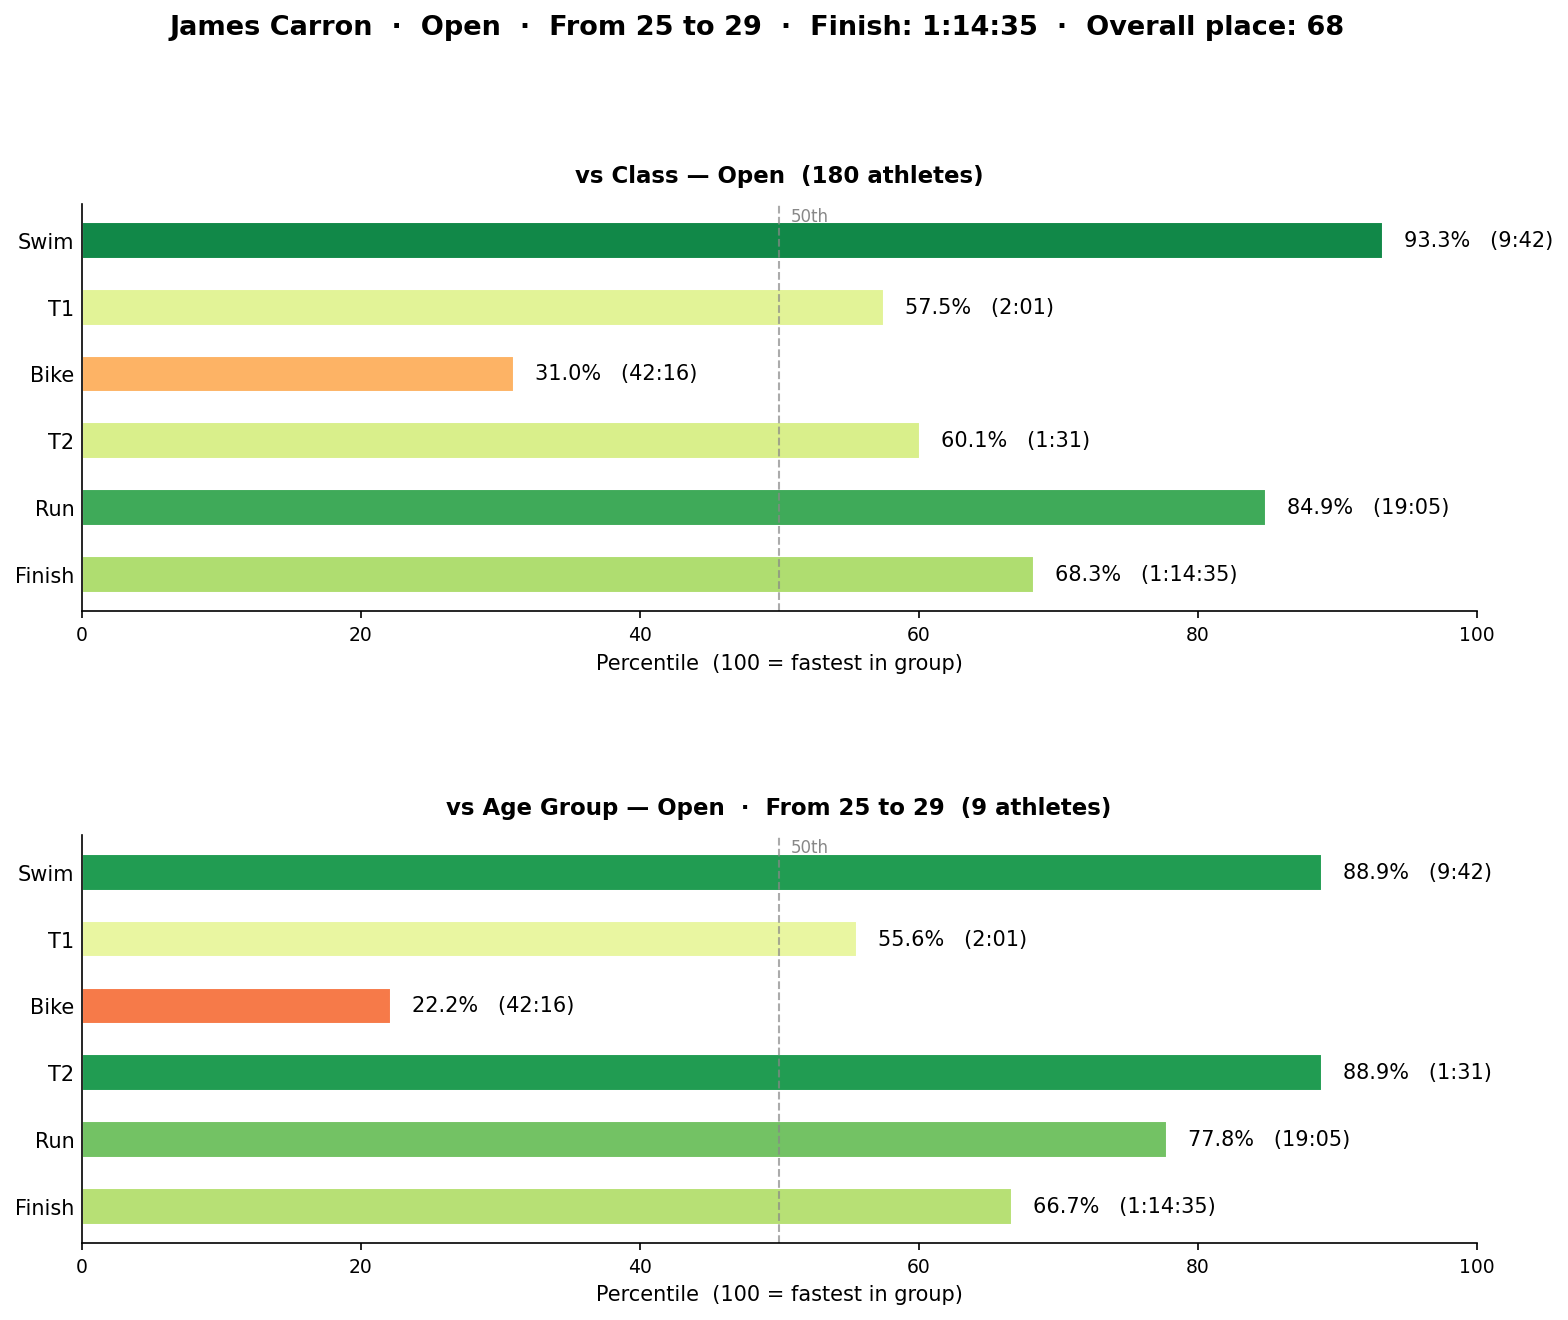

In [33]:
from visualise import plot_athlete, plot_athlete_extended

plot_athlete('James Carron', df)

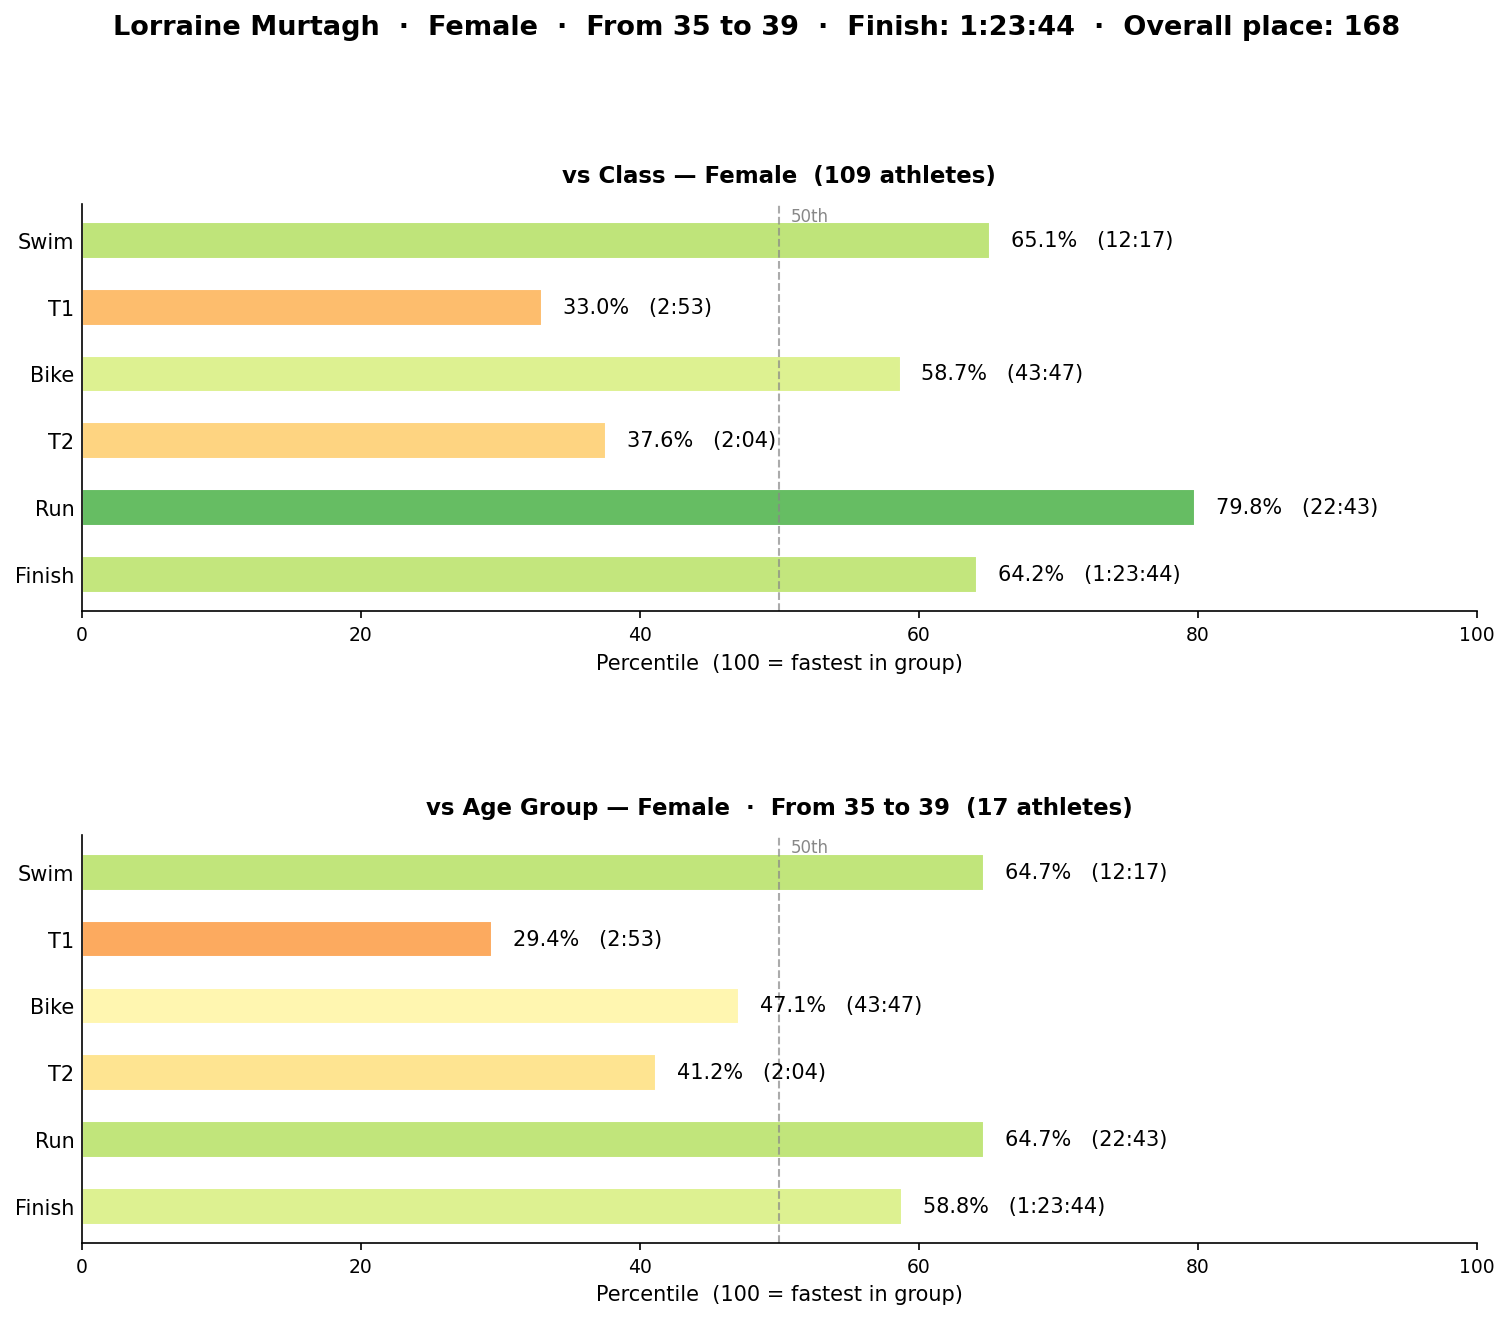

In [34]:
plot_athlete('Lorraine Murtagh', df)

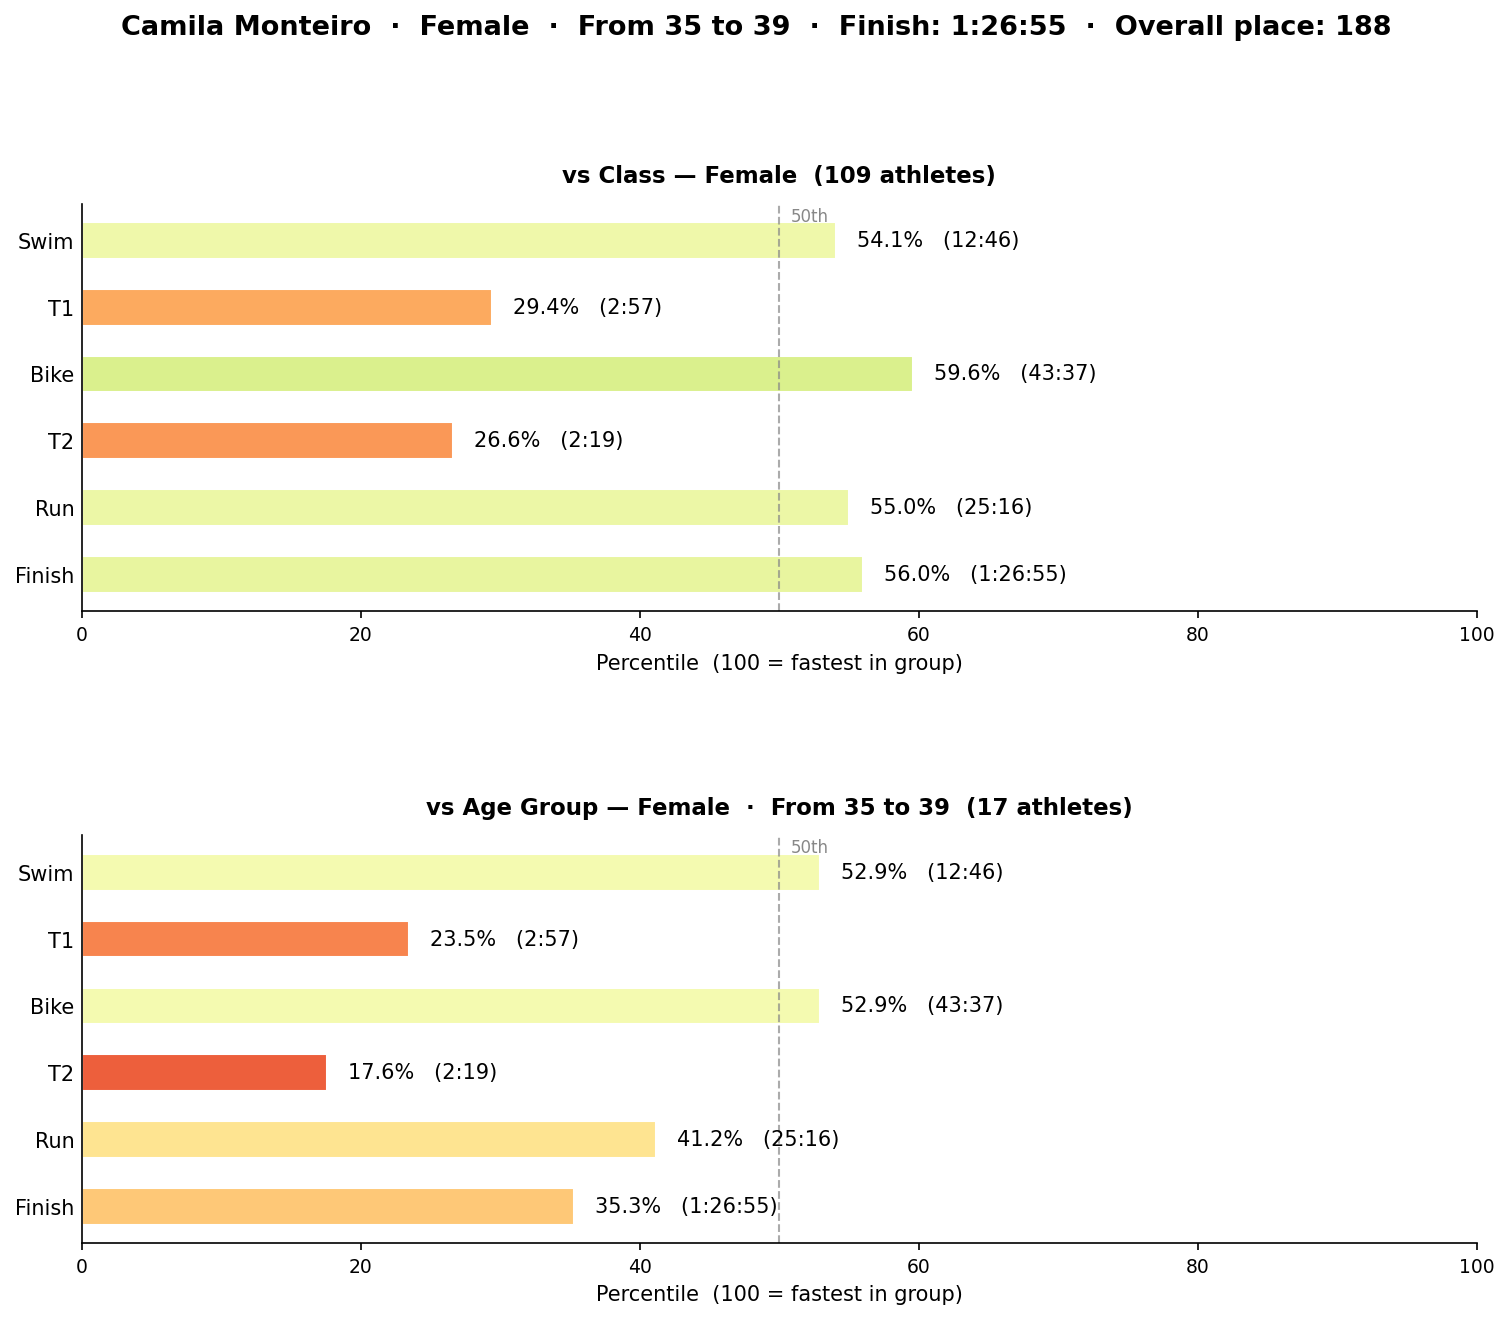

In [35]:
plot_athlete('Camila Monteiro', df)

### 3a · Extended view — all percentile groupings

`plot_athlete_extended` shows four panels for each athlete:
1. **vs Class** — same as the top panel in `plot_athlete`
2. **vs Whole Race** — all classes combined (`pct_overall`)
3. **vs Age Group** — within class + age band (`pct_ag`)
4. **Normalised** — each split as % of the athlete's own best split; 100 = strongest discipline, lower = relative weakness (`pct_norm`)

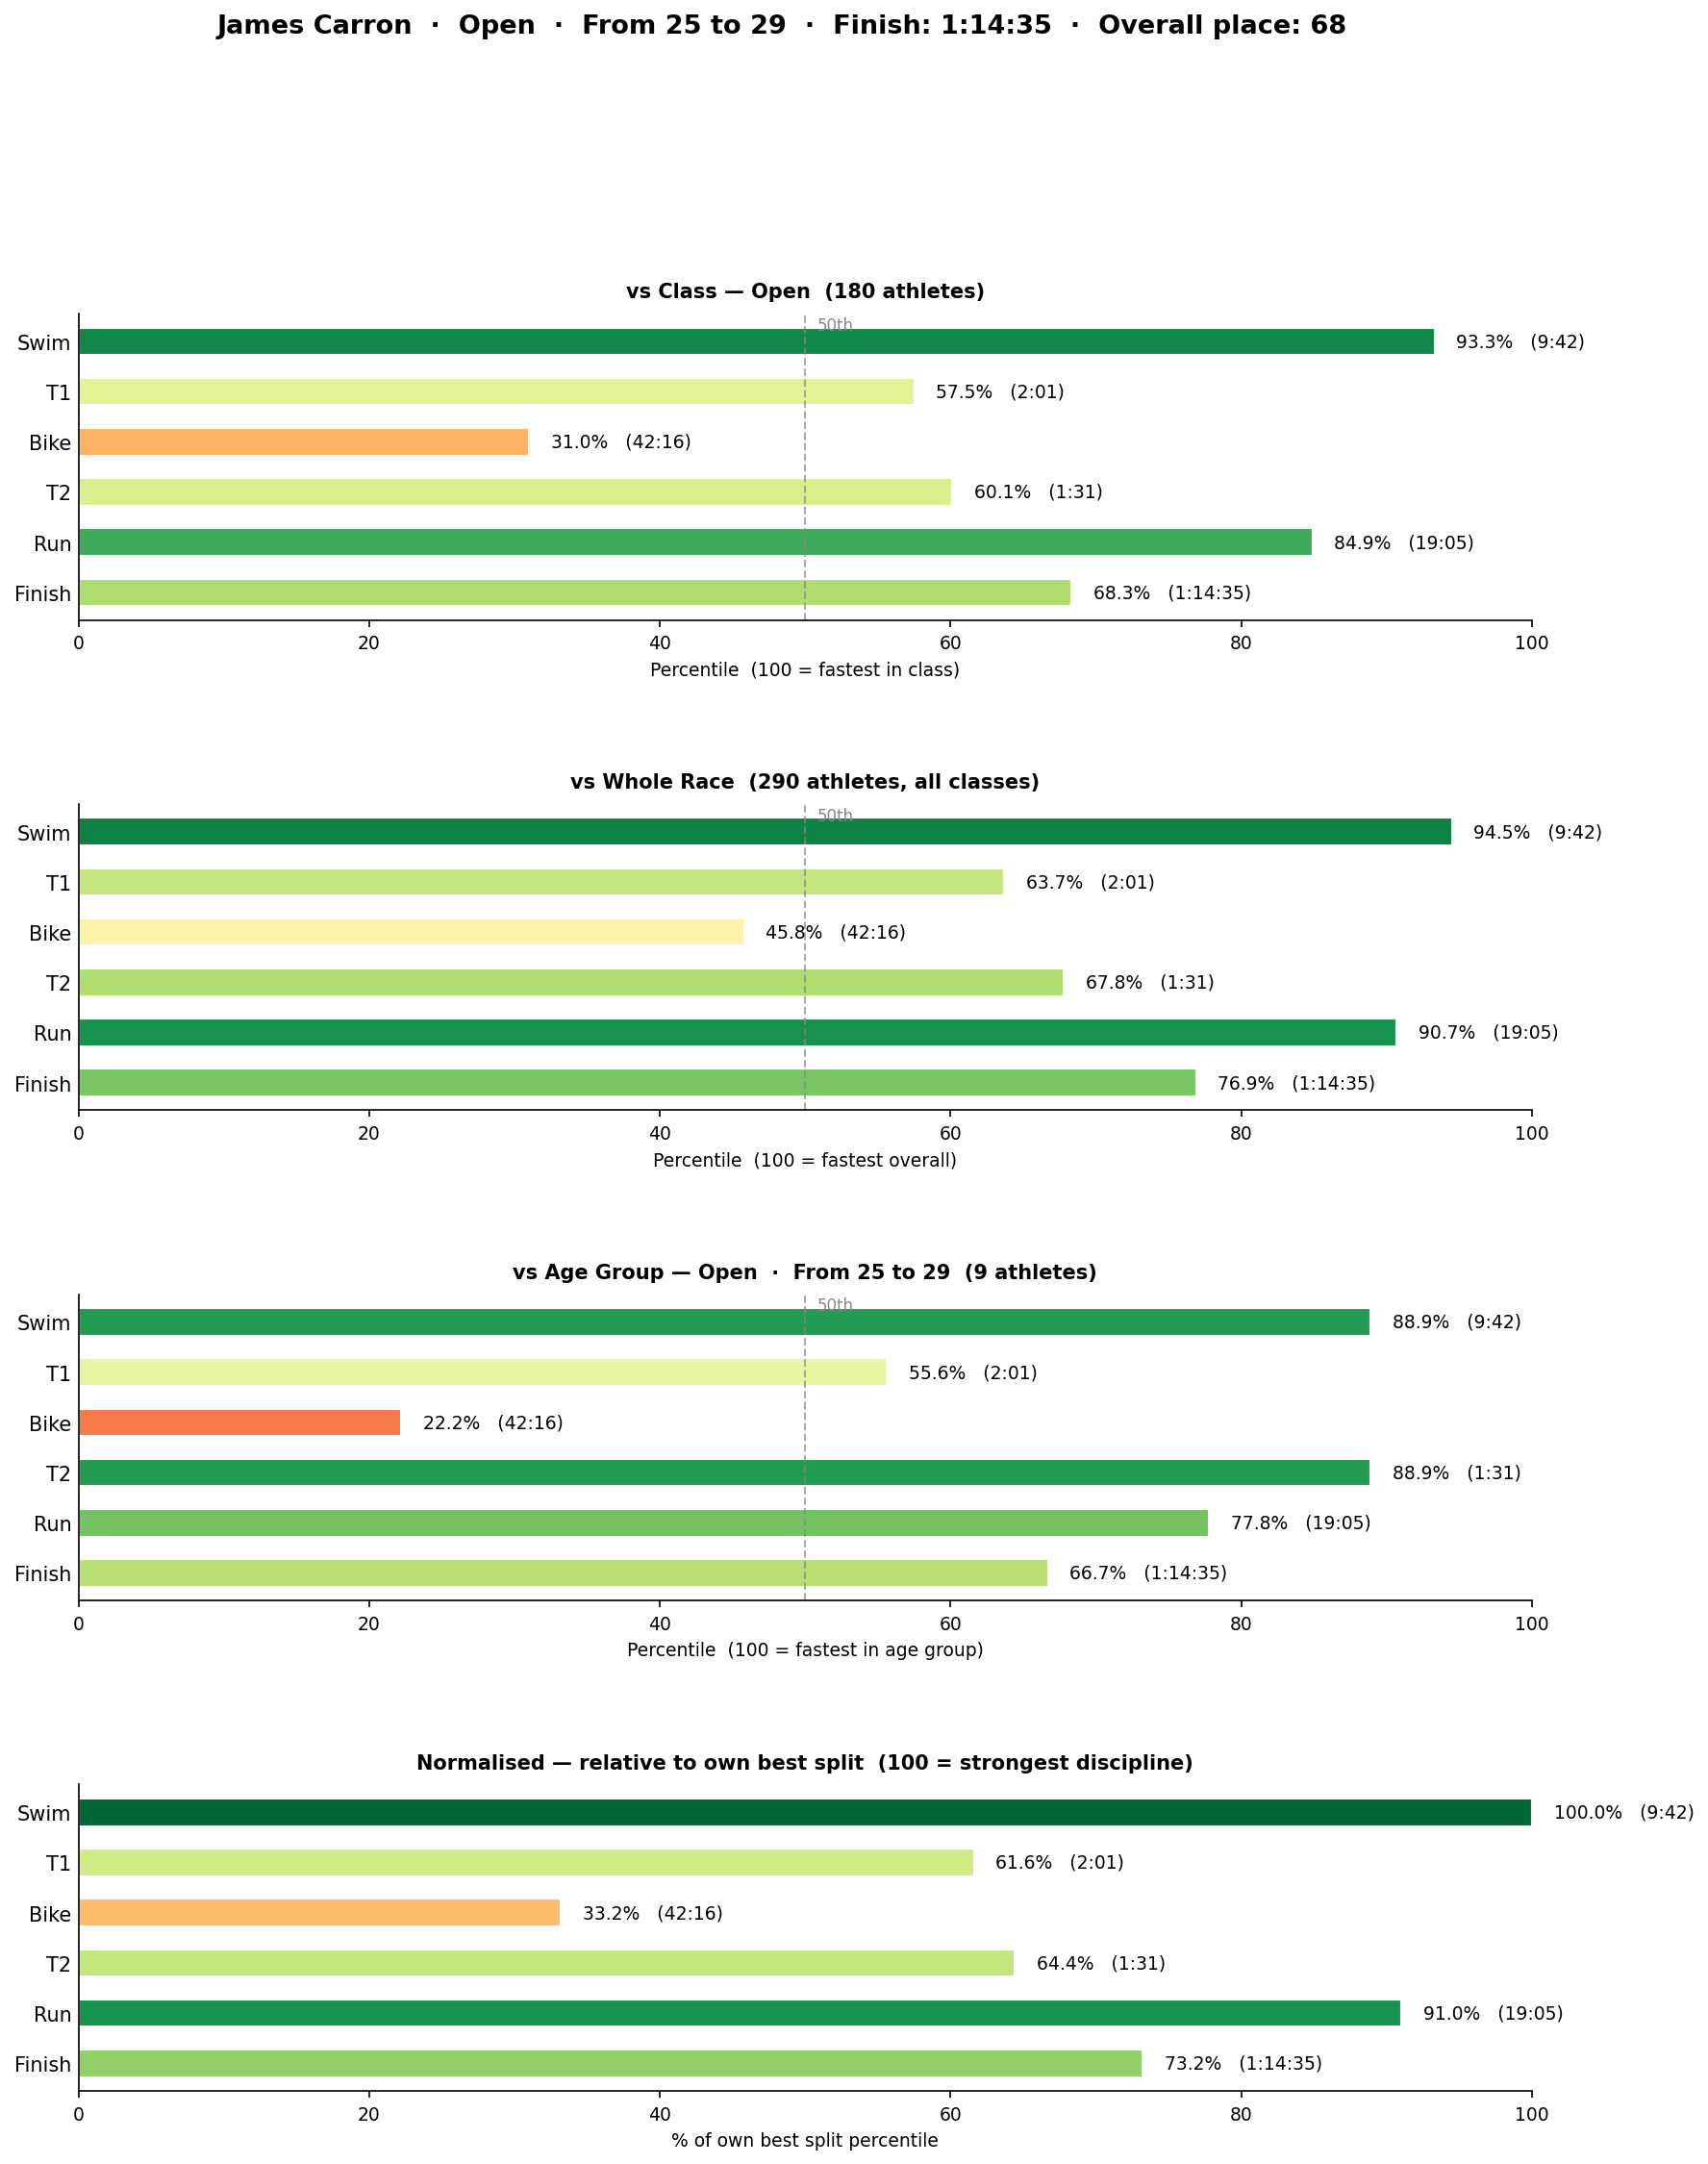

In [36]:
plot_athlete_extended('James Carron', df)

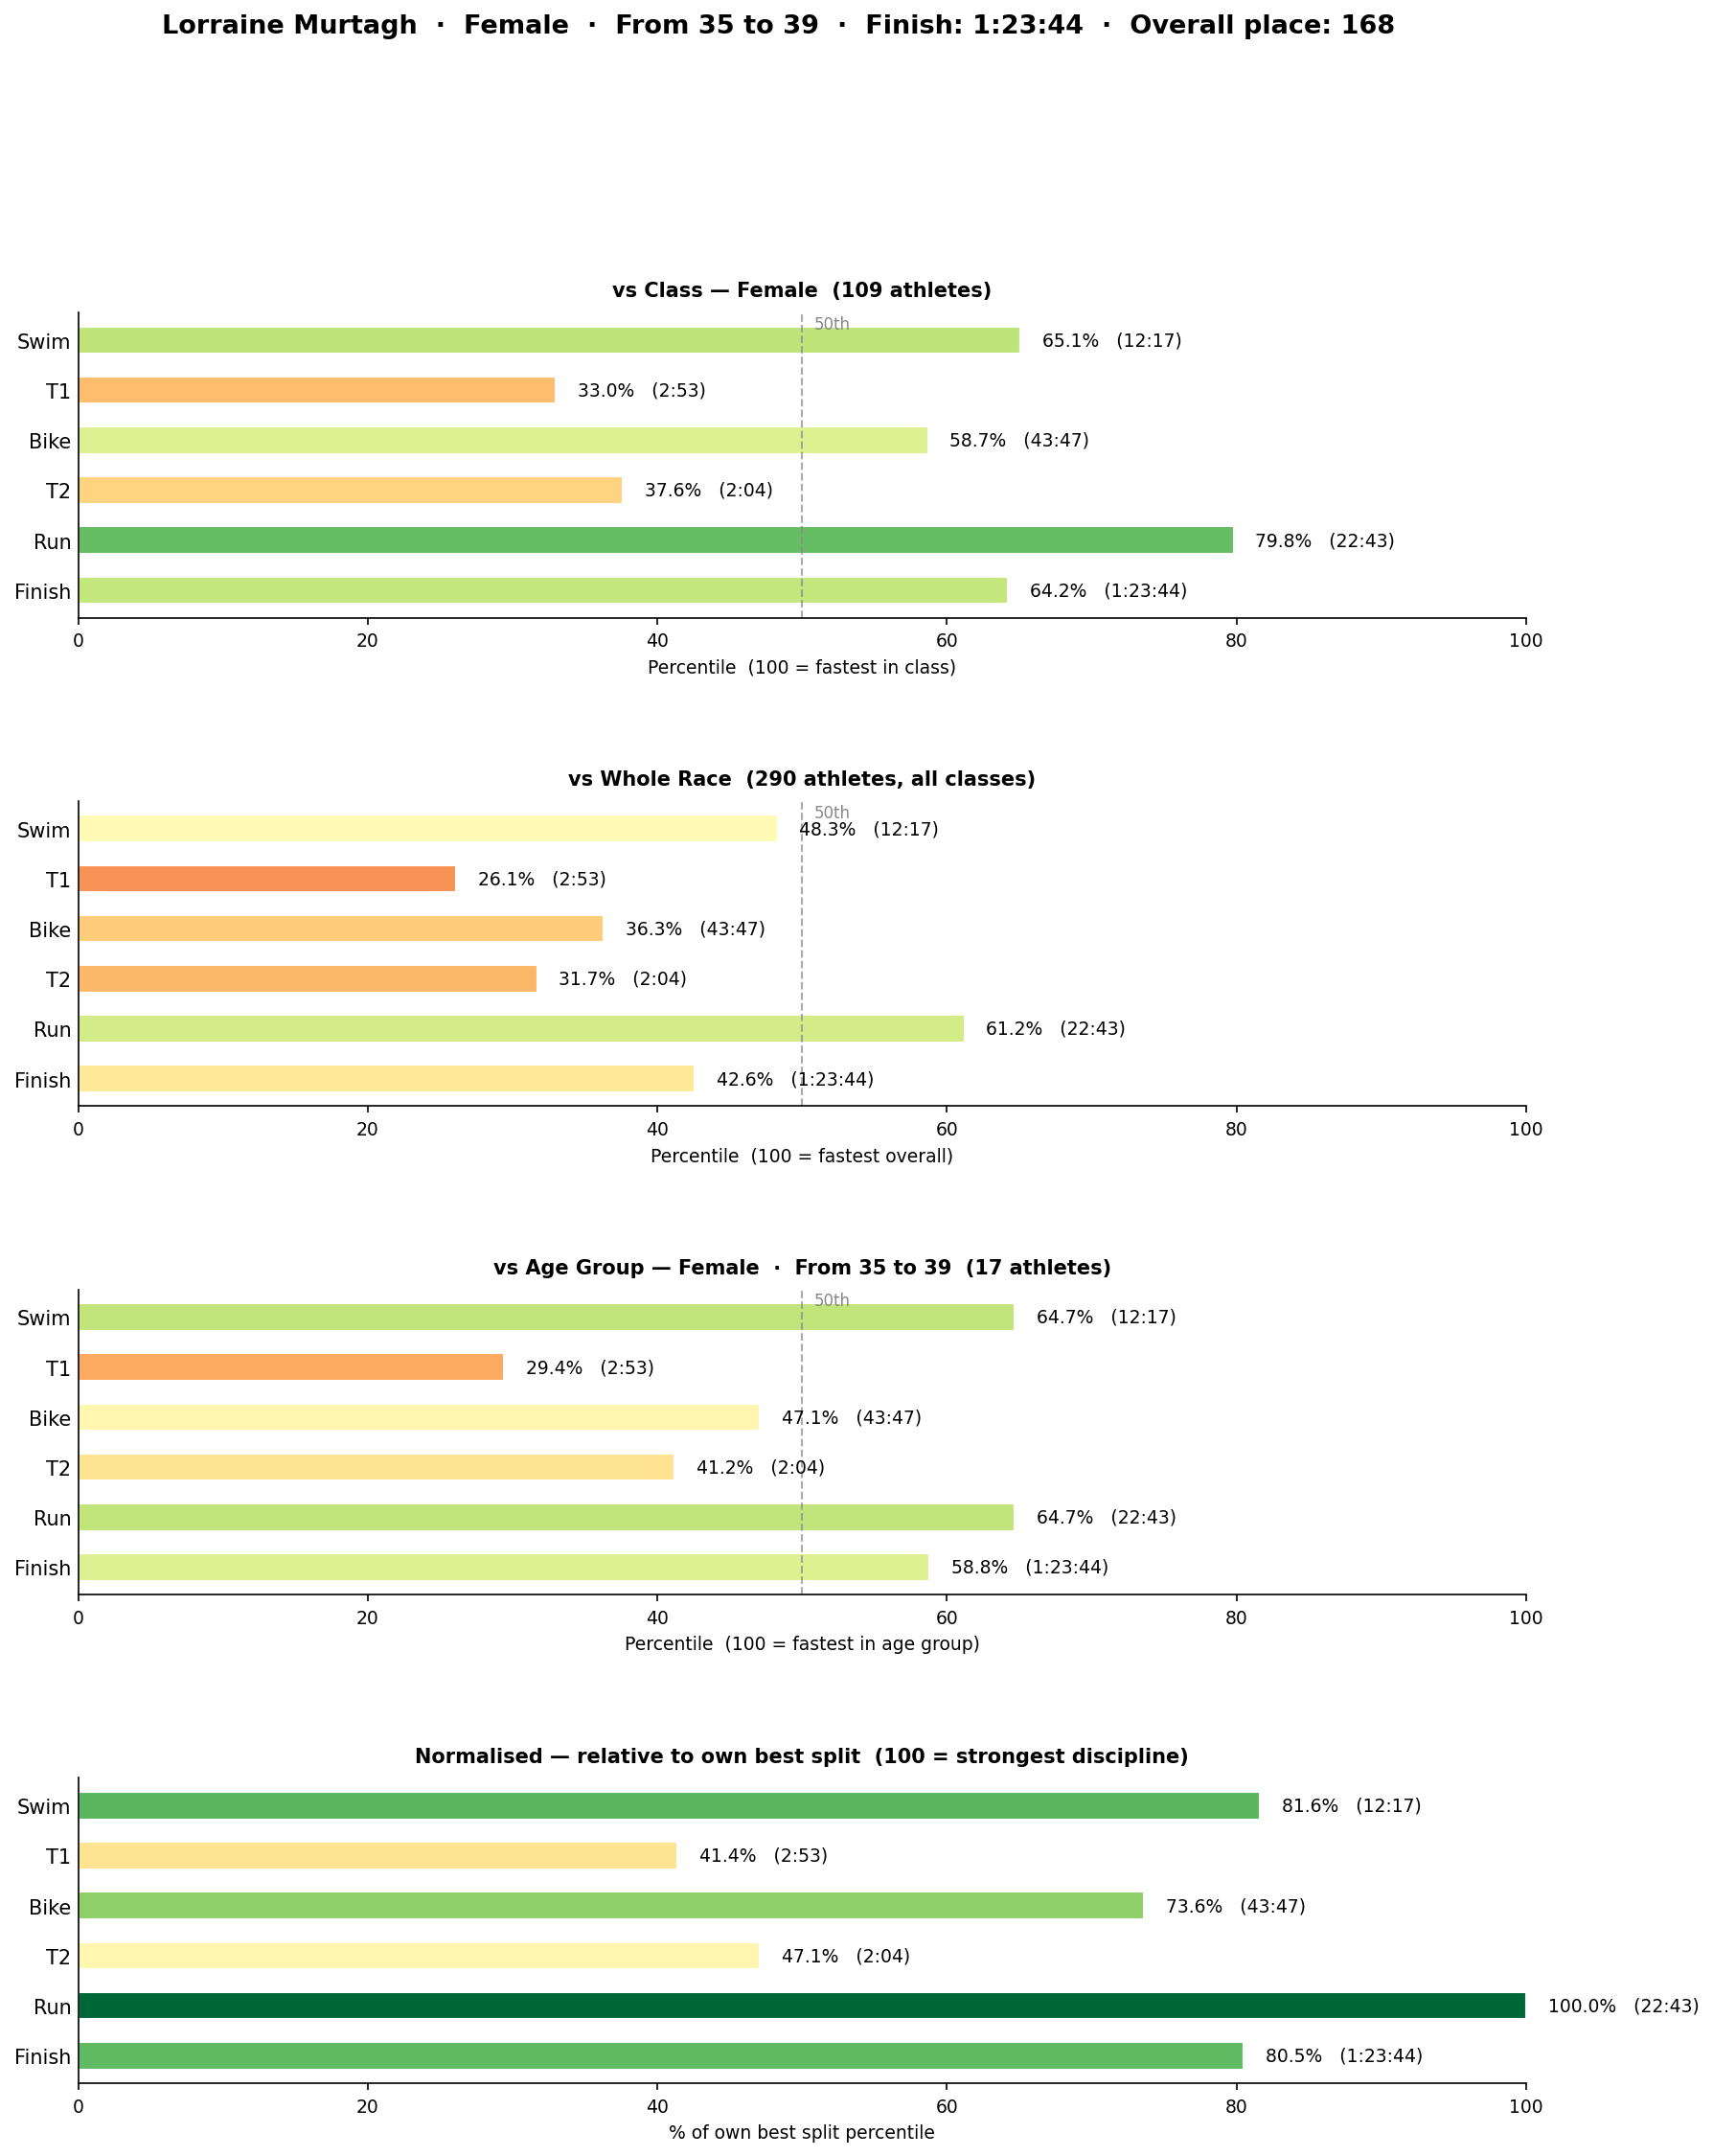

In [37]:
plot_athlete_extended('Lorraine Murtagh', df)

In [1]:
(25.5-21)/21 * 35

7.5

In [ ]:
plot_athlete_extended('Camila Monteiro', df)

## Quick sanity checks

In [ ]:
# Top 10 finishers
df.sort_values('Finish').head(10)[['Place', 'Bib', 'Name', 'Age_Group', 'Class', 'Club', 'Finish']]

In [ ]:
# Breakdown by class
df['Class'].value_counts()

In [ ]:
# Fastest swim, bike, and run splits
for col in ['Swim', 'Bike', 'Run']:
    idx = df[col].idxmin()
    row = df.loc[idx]
    print(f'Fastest {col}: {row["Name"]} — {row[col]}')